<a href="https://colab.research.google.com/github/aabyyaann/scikit-learn-Cookbook/blob/main/Chapter8_Tree_Based_Algorithms_and_Ensemble_Methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 8 - Tree-Based Algorithms and Ensemble Methods

Notebook ini membahas algoritma berbasis pohon keputusan dan ensemble methods menggunakan `scikit-learn Cookbook`.

Topik utama pada chapter ini meliputi:
1. Introduction to Decision Trees
2. Random Forests and Bagging
3. Gradient Boosting Machines
4. Hyperparameter Tuning for Trees and Ensembles
5. Comparing Ensemble Methods
6. Practical Exercises with Tree-Based Models

Tujuan chapter ini adalah memahami bagaimana model pohon bekerja, bagaimana ensemble meningkatkan performa model, serta bagaimana membandingkan beberapa pendekatan tree-based pada dataset klasifikasi.

## Ringkasan Teori

Model berbasis pohon termasuk keluarga algoritma supervised learning yang sangat populer karena:
- mudah dipahami dan divisualisasikan,
- dapat menangani hubungan non-linear,
- tidak terlalu sensitif terhadap skala fitur,
- bisa digunakan untuk klasifikasi maupun regresi.

Pada chapter ini kita akan mempelajari beberapa model penting:

### 1. Decision Tree
Decision Tree membagi data ke dalam beberapa cabang berdasarkan aturan tertentu.  
Kelebihannya adalah interpretasi yang mudah, tetapi model ini rawan **overfitting** jika pohon terlalu dalam.

### 2. Random Forest
Random Forest adalah kumpulan banyak decision tree yang dilatih pada subset data dan subset fitur yang berbeda.  
Tujuannya adalah mengurangi overfitting dan meningkatkan generalisasi.

### 3. Bagging
Bagging (Bootstrap Aggregating) adalah teknik ensemble yang melatih banyak model pada sampel bootstrap lalu menggabungkan hasilnya.

### 4. Gradient Boosting
Gradient Boosting membangun model secara bertahap. Setiap model baru mencoba memperbaiki kesalahan model sebelumnya.  
Model ini sering memberikan performa tinggi, tetapi perlu tuning parameter yang baik.

### 5. Hyperparameter Tuning
Beberapa parameter penting pada model tree-based:
- `max_depth`
- `min_samples_split`
- `min_samples_leaf`
- `n_estimators`
- `learning_rate`

### 6. Perbandingan Model
Di akhir chapter, kita akan membandingkan:
- Decision Tree
- Random Forest
- Gradient Boosting

dari sisi akurasi dan performa generalisasi.

In [1]:
# Import library utama
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Pengaturan tampilan
plt.style.use("default")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

print("Library untuk Chapter 8 berhasil diimpor.")

Library untuk Chapter 8 berhasil diimpor.


## 1. Introduction to Decision Trees

Decision Tree adalah model yang membagi data menjadi beberapa subset menggunakan aturan if-else berdasarkan fitur tertentu.

Pada klasifikasi, decision tree memilih split yang paling baik untuk memisahkan kelas.  
Model ini mudah dipahami, tetapi jika dibiarkan tumbuh tanpa batas, ia bisa menghafal data training dan menyebabkan overfitting.

Pada bagian ini kita akan:
- memuat dataset klasifikasi,
- melatih decision tree dasar,
- mengevaluasi performa model,
- melihat visualisasi struktur pohon.

In [3]:
# Load dataset breast cancer
cancer = load_breast_cancer()

X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target, name="target")

print("Ukuran data:", X.shape)
print("Nama target:", cancer.target_names)
X.head()

Ukuran data: (569, 30)
Nama target: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
# Melihat distribusi target
target_counts = y.value_counts().sort_index()
target_df = pd.DataFrame({
    "kelas": cancer.target_names,
    "jumlah": target_counts.values
})

target_df

,kelas,jumlah
0,malignant,212
1,benign,357


In [5]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Ukuran data latih :", X_train.shape)
print("Ukuran data uji   :", X_test.shape)

Ukuran data latih : (426, 30)
Ukuran data uji   : (143, 30)


In [6]:
# Decision Tree tanpa pembatasan kedalaman
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

train_score = tree.score(X_train, y_train)
test_score = tree.score(X_test, y_test)

print("Decision Tree tanpa pruning")
print("Training accuracy:", round(train_score, 4))
print("Test accuracy    :", round(test_score, 4))

Decision Tree tanpa pruning
Training accuracy: 1.0
Test accuracy    : 0.9231


Hasil di atas biasanya menunjukkan bahwa akurasi training sangat tinggi, bahkan bisa mendekati 100%.  
Namun akurasi test belum tentu setinggi itu. Ini adalah tanda bahwa decision tree tanpa pembatasan mudah mengalami **overfitting**.

In [7]:
# Decision Tree dengan pre-pruning
tree_pruned = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_pruned.fit(X_train, y_train)

train_score_pruned = tree_pruned.score(X_train, y_train)
test_score_pruned = tree_pruned.score(X_test, y_test)

print("Decision Tree dengan max_depth=4")
print("Training accuracy:", round(train_score_pruned, 4))
print("Test accuracy    :", round(test_score_pruned, 4))

Decision Tree dengan max_depth=4
Training accuracy: 0.9883
Test accuracy    : 0.9441


In [8]:
# Perbandingan hasil decision tree
comparison_tree = pd.DataFrame({
    "Model": ["Decision Tree Default", "Decision Tree max_depth=4"],
    "Training Accuracy": [train_score, train_score_pruned],
    "Test Accuracy": [test_score, test_score_pruned]
})

comparison_tree

,Model,Training Accuracy,Test Accuracy
0,Decision Tree Default,1.000000,0.923077
1,Decision Tree max_depth=4,0.988263,0.944056


In [9]:
# Evaluasi model pruned tree
y_pred_tree = tree_pruned.predict(X_test)

print("Classification Report - Decision Tree (max_depth=4)")
print(classification_report(y_test, y_pred_tree, target_names=cancer.target_names))

Classification Report - Decision Tree (max_depth=4)
              precision    recall  f1-score   support

   malignant       0.92      0.92      0.92        53
      benign       0.96      0.96      0.96        90

    accuracy                           0.94       143
   macro avg       0.94      0.94      0.94       143
weighted avg       0.94      0.94      0.94       143



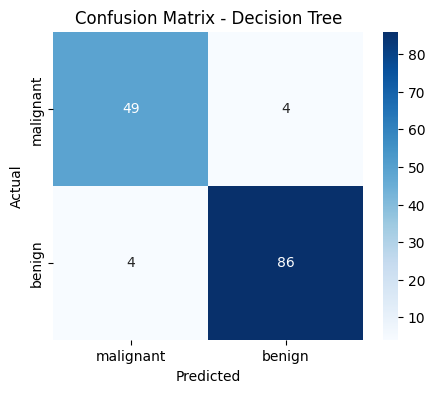

In [10]:
# Confusion matrix decision tree
cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_tree, annot=True, fmt="d", cmap="Blues",
            xticklabels=cancer.target_names,
            yticklabels=cancer.target_names)
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

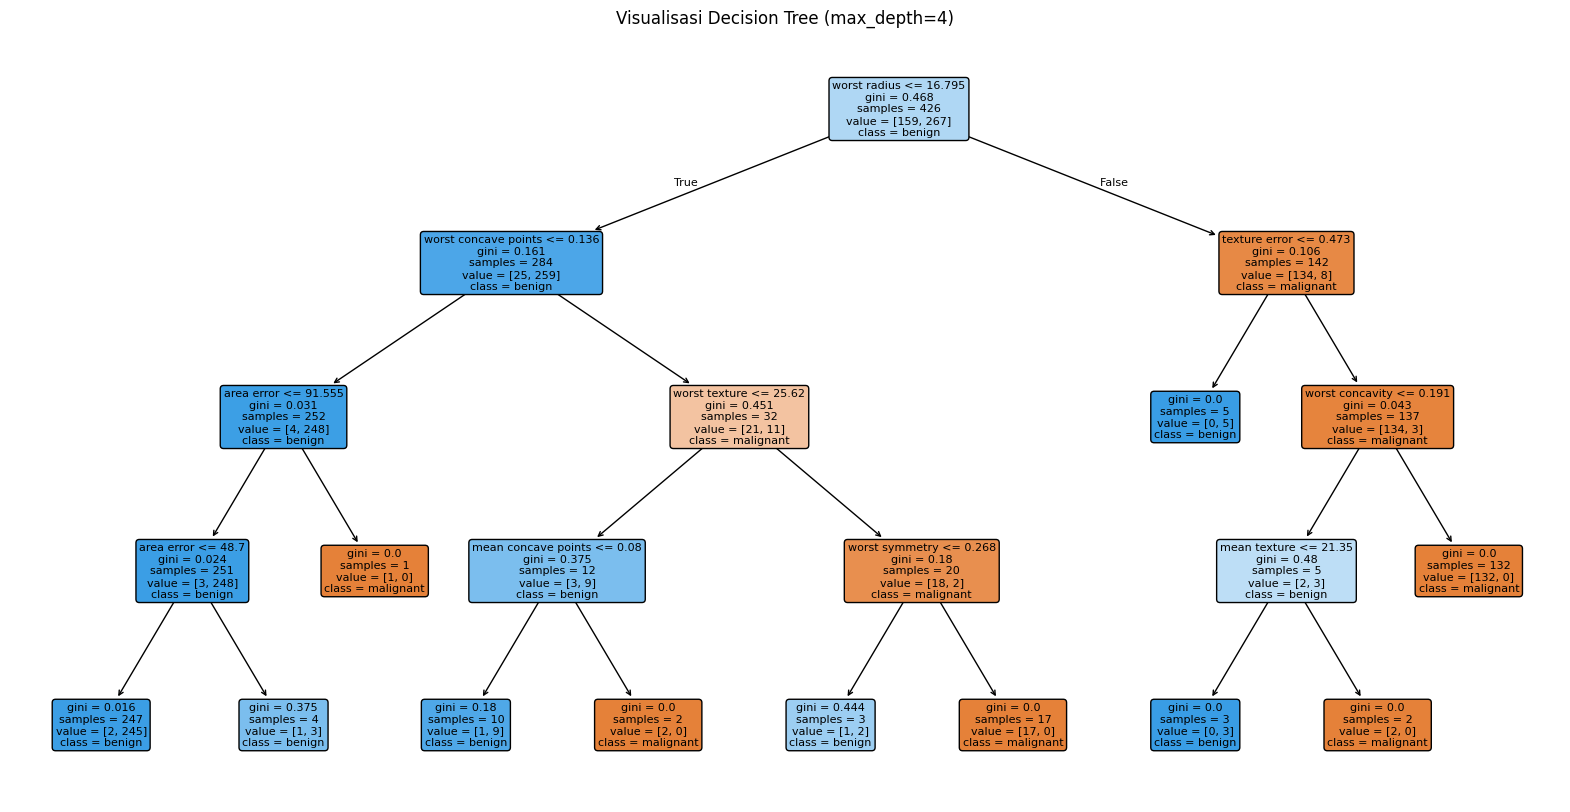

In [11]:
# Visualisasi pohon
plt.figure(figsize=(20, 10))
plot_tree(
    tree_pruned,
    filled=True,
    feature_names=X.columns,
    class_names=cancer.target_names,
    rounded=True,
    fontsize=8
)
plt.title("Visualisasi Decision Tree (max_depth=4)")
plt.show()

### Interpretasi Singkat
Beberapa hal penting dari decision tree:

- Pohon membagi data berdasarkan fitur yang paling informatif.
- Node paling atas biasanya memuat fitur yang paling kuat untuk memisahkan kelas.
- Semakin dalam pohon, semakin kompleks aturan yang dipelajari.
- Pembatasan seperti `max_depth` membantu mencegah overfitting.

## 2. Random Forests and Bagging

Decision Tree tunggal mudah overfit. Salah satu solusi adalah menggunakan **ensemble**, yaitu menggabungkan banyak model.

### Random Forest
Random Forest membuat banyak decision tree dan menggabungkan prediksi semuanya.  
Setiap tree dilatih menggunakan:
- sampel data bootstrap,
- subset fitur yang dipilih secara acak.

### Bagging
Bagging juga membuat banyak model dari sampel bootstrap, lalu menggabungkan hasilnya.  
Pada bagian ini kita akan membandingkan Random Forest dan Bagging terhadap Decision Tree tunggal.

In [12]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)
rf.fit(X_train, y_train)

rf_train_score = rf.score(X_train, y_train)
rf_test_score = rf.score(X_test, y_test)

print("Random Forest")
print("Training accuracy:", round(rf_train_score, 4))
print("Test accuracy    :", round(rf_test_score, 4))

Random Forest
Training accuracy: 0.993
Test accuracy    : 0.951


In [13]:
# Bagging dengan base estimator decision tree
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    random_state=42
)
bagging.fit(X_train, y_train)

bag_train_score = bagging.score(X_train, y_train)
bag_test_score = bagging.score(X_test, y_test)

print("Bagging Classifier")
print("Training accuracy:", round(bag_train_score, 4))
print("Test accuracy    :", round(bag_test_score, 4))

Bagging Classifier
Training accuracy: 1.0
Test accuracy    : 0.951


In [14]:
# Ringkasan perbandingan sementara
comparison_ensemble = pd.DataFrame({
    "Model": [
        "Decision Tree max_depth=4",
        "Random Forest",
        "Bagging Classifier"
    ],
    "Training Accuracy": [
        train_score_pruned,
        rf_train_score,
        bag_train_score
    ],
    "Test Accuracy": [
        test_score_pruned,
        rf_test_score,
        bag_test_score
    ]
})

comparison_ensemble.sort_values("Test Accuracy", ascending=False)

,Model,Training Accuracy,Test Accuracy
1,Random Forest,0.992958,0.951049
2,Bagging Classifier,1.000000,0.951049
0,Decision Tree max_depth=4,0.988263,0.944056


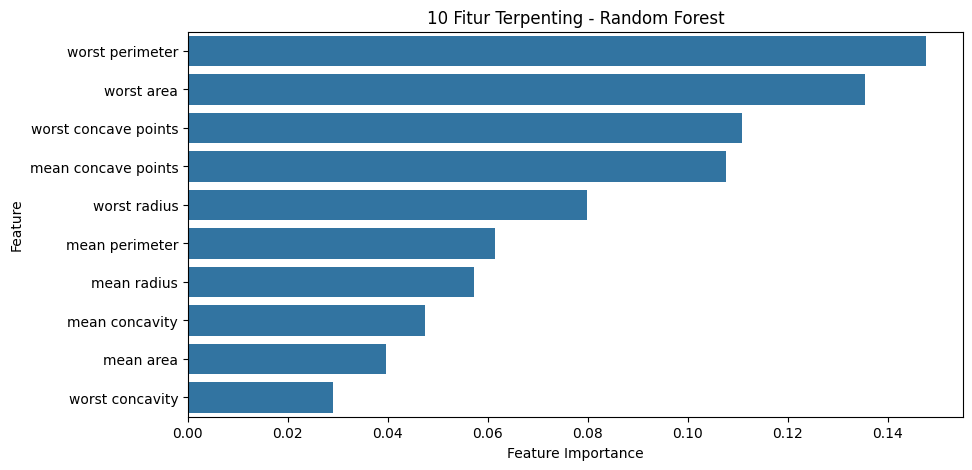

In [15]:
# Feature importance dari Random Forest
rf_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=rf_importance.values, y=rf_importance.index)
plt.title("10 Fitur Terpenting - Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()

### Interpretasi Random Forest
Random Forest biasanya lebih stabil dibanding satu decision tree karena:
- prediksi diambil dari banyak pohon,
- pengaruh noise dari satu pohon menjadi lebih kecil,
- model lebih tahan terhadap overfitting.

Selain itu, Random Forest juga menyediakan **feature importance** yang membantu kita memahami fitur mana yang paling berpengaruh terhadap prediksi.

## 3. Gradient Boosting Machines

Gradient Boosting membangun model secara bertahap.  
Berbeda dari bagging yang melatih model secara paralel, boosting melatih model secara **berurutan**, di mana model baru mencoba memperbaiki kesalahan model sebelumnya.

Parameter penting pada Gradient Boosting:
- `n_estimators`: jumlah pohon
- `learning_rate`: seberapa besar kontribusi tiap pohon
- `max_depth`: kompleksitas tiap pohon dasar

Model ini sering memberikan performa sangat baik, tetapi perlu tuning parameter yang cukup hati-hati.

In [16]:
# Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb.fit(X_train, y_train)

gb_train_score = gb.score(X_train, y_train)
gb_test_score = gb.score(X_test, y_test)

print("Gradient Boosting")
print("Training accuracy:", round(gb_train_score, 4))
print("Test accuracy    :", round(gb_test_score, 4))

Gradient Boosting
Training accuracy: 1.0
Test accuracy    : 0.958


In [17]:
# Classification report Gradient Boosting
y_pred_gb = gb.predict(X_test)

print("Classification Report - Gradient Boosting")
print(classification_report(y_test, y_pred_gb, target_names=cancer.target_names))

Classification Report - Gradient Boosting
              precision    recall  f1-score   support

   malignant       0.98      0.91      0.94        53
      benign       0.95      0.99      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143



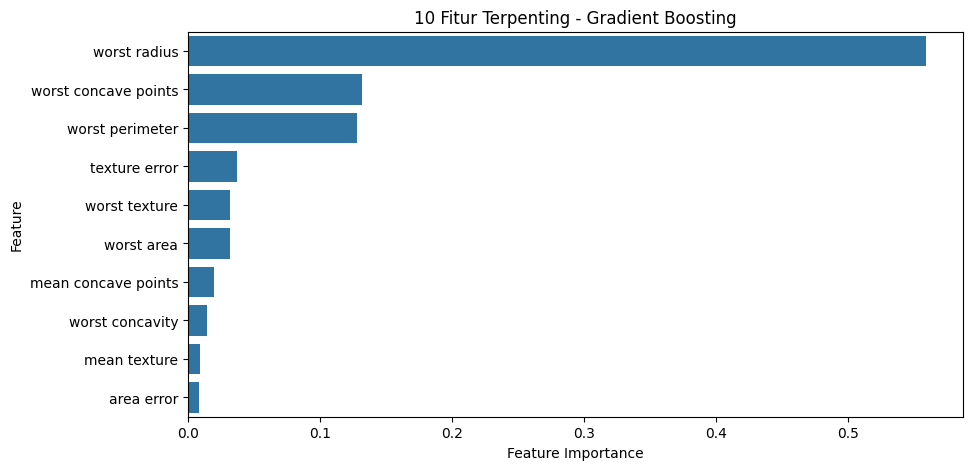

In [18]:
# Feature importance Gradient Boosting
gb_importance = pd.Series(gb.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=gb_importance.values, y=gb_importance.index)
plt.title("10 Fitur Terpenting - Gradient Boosting")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()

In [19]:
# Perbandingan 3 model utama
comparison_models = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Bagging",
        "Gradient Boosting"
    ],
    "Training Accuracy": [
        train_score_pruned,
        rf_train_score,
        bag_train_score,
        gb_train_score
    ],
    "Test Accuracy": [
        test_score_pruned,
        rf_test_score,
        bag_test_score,
        gb_test_score
    ]
})

comparison_models.sort_values("Test Accuracy", ascending=False)

,Model,Training Accuracy,Test Accuracy
3,Gradient Boosting,1.000000,0.958042
1,Random Forest,0.992958,0.951049
2,Bagging,1.000000,0.951049
0,Decision Tree,0.988263,0.944056


## 4. Hyperparameter Tuning for Trees and Ensembles

Setelah membuat model dasar, langkah berikutnya adalah mencari kombinasi parameter yang lebih baik.

Pada model tree-based, parameter yang umum dituning antara lain:
- `max_depth`
- `min_samples_split`
- `min_samples_leaf`
- `n_estimators`
- `max_features`

Di bagian ini kita akan melakukan tuning pada Random Forest menggunakan `GridSearchCV`.

In [20]:
# Grid search untuk Random Forest
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best parameters:", grid_rf.best_params_)
print("Best CV score  :", round(grid_rf.best_score_, 4))
print("Test score     :", round(grid_rf.score(X_test, y_test), 4))

Best parameters: {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV score  : 0.9624
Test score     : 0.958


In [21]:
# Model terbaik hasil tuning
best_rf = grid_rf.best_estimator_
best_rf_train = best_rf.score(X_train, y_train)
best_rf_test = best_rf.score(X_test, y_test)

print("Random Forest terbaik setelah tuning")
print("Training accuracy:", round(best_rf_train, 4))
print("Test accuracy    :", round(best_rf_test, 4))

Random Forest terbaik setelah tuning
Training accuracy: 0.9977
Test accuracy    : 0.958


In [22]:
# Hasil grid search dalam bentuk tabel
results_rf = pd.DataFrame(grid_rf.cv_results_)

cols_to_show = [
    "param_n_estimators",
    "param_max_depth",
    "param_min_samples_split",
    "param_min_samples_leaf",
    "mean_test_score",
    "rank_test_score"
]

results_rf[cols_to_show].sort_values("rank_test_score").head(10)

,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,mean_test_score,rank_test_score
25,100,7,2,1,0.962408,1
26,200,7,2,1,0.960055,2
31,100,7,2,2,0.960055,2
44,200,None,2,2,0.960055,2
37,100,None,2,1,0.960055,2
38,200,None,2,1,0.960055,2
35,200,7,5,2,0.960055,2
32,200,7,2,2,0.960055,2
47,200,None,5,2,0.960055,2
43,100,None,2,2,0.960055,2


### Catatan
Grid Search mencoba berbagai kombinasi parameter lalu mengevaluasinya menggunakan cross-validation.  
Tujuannya adalah mencari model yang tidak hanya bagus pada data training, tetapi juga stabil pada data yang belum pernah dilihat.

## 5. Comparing Ensemble Methods

Sekarang kita akan membandingkan beberapa model ensemble secara langsung:
- Random Forest default
- Random Forest hasil tuning
- Bagging
- Gradient Boosting

Perbandingan dilakukan menggunakan akurasi pada data training dan data test.

In [23]:
comparison_final = pd.DataFrame({
    "Model": [
        "Decision Tree max_depth=4",
        "Random Forest",
        "Random Forest Tuned",
        "Bagging",
        "Gradient Boosting"
    ],
    "Training Accuracy": [
        train_score_pruned,
        rf_train_score,
        best_rf_train,
        bag_train_score,
        gb_train_score
    ],
    "Test Accuracy": [
        test_score_pruned,
        rf_test_score,
        best_rf_test,
        bag_test_score,
        gb_test_score
    ]
})

comparison_final = comparison_final.sort_values("Test Accuracy", ascending=False)
comparison_final

,Model,Training Accuracy,Test Accuracy
2,Random Forest Tuned,0.997653,0.958042
4,Gradient Boosting,1.000000,0.958042
1,Random Forest,0.992958,0.951049
3,Bagging,1.000000,0.951049
0,Decision Tree max_depth=4,0.988263,0.944056


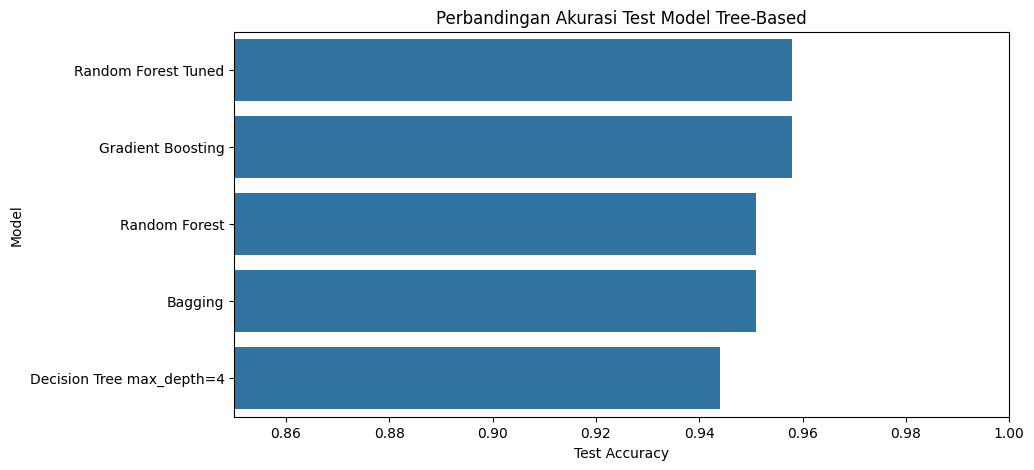

In [24]:
# Visualisasi perbandingan akurasi test
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_final, x="Test Accuracy", y="Model")
plt.title("Perbandingan Akurasi Test Model Tree-Based")
plt.xlim(0.85, 1.0)
plt.show()

In [25]:
# Menampilkan feature importance dari model terbaik (jika model terbaik adalah random forest tuned)
best_model_name = comparison_final.iloc[0]["Model"]
print("Model dengan test accuracy tertinggi:", best_model_name)

Model dengan test accuracy tertinggi: Random Forest Tuned


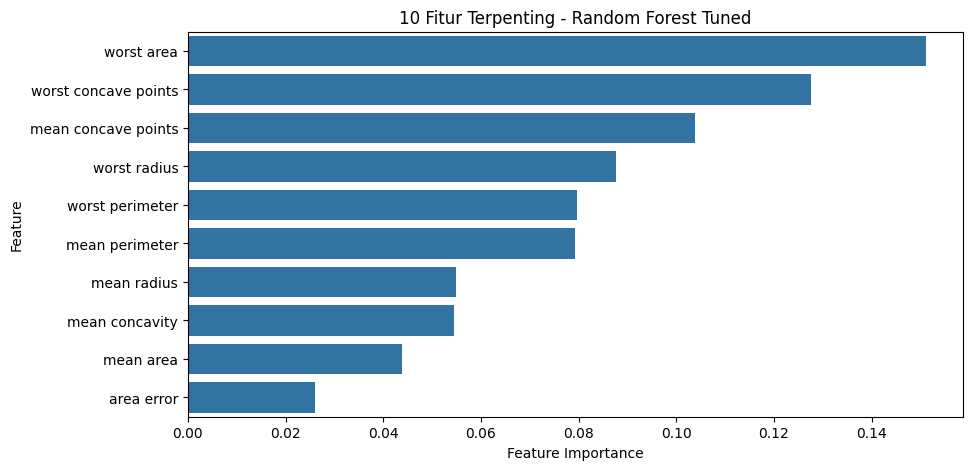

In [26]:
# Feature importance dari best_rf
best_rf_importance = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=best_rf_importance.values, y=best_rf_importance.index)
plt.title("10 Fitur Terpenting - Random Forest Tuned")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()

## 6. Practical Exercises with Tree-Based Models

Pada bagian ini kita membuat latihan singkat yang merepresentasikan isi chapter:
1. Membangun decision tree classifier sederhana
2. Melakukan tuning random forest
3. Membandingkan gradient boosting dan random forest

Agar latihan tidak terlalu berat, kita akan menggunakan dataset `wine`.

In [27]:
# Load dataset wine
wine = load_wine()

X_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
y_wine = pd.Series(wine.target, name="target")

Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_wine, y_wine, test_size=0.25, random_state=42, stratify=y_wine
)

print("Ukuran data wine:", X_wine.shape)
X_wine.head()

Ukuran data wine: (178, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


### Exercise 1 - Decision Tree Classifier
Kita mulai dari model decision tree sederhana untuk memprediksi kelas wine.

In [28]:
dt_wine = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_wine.fit(Xw_train, yw_train)

pred_dt_wine = dt_wine.predict(Xw_test)

print("Decision Tree - Wine")
print("Accuracy:", round(accuracy_score(yw_test, pred_dt_wine), 4))
print(classification_report(yw_test, pred_dt_wine))

Decision Tree - Wine
Accuracy: 0.9556
              precision    recall  f1-score   support

           0       1.00      0.93      0.97        15
           1       0.90      1.00      0.95        18
           2       1.00      0.92      0.96        12

    accuracy                           0.96        45
   macro avg       0.97      0.95      0.96        45
weighted avg       0.96      0.96      0.96        45



### Exercise 2 - Hyperparameter Tuning dengan Random Forest
Sekarang kita cari kombinasi parameter yang lebih baik untuk random forest pada dataset wine.

In [29]:
param_grid_wine = {
    "n_estimators": [50, 100, 150],
    "max_depth": [3, 5, None]
}

grid_wine = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid_wine,
    cv=5,
    n_jobs=-1
)

grid_wine.fit(Xw_train, yw_train)

print("Best parameters:", grid_wine.best_params_)
print("Best CV score  :", round(grid_wine.best_score_, 4))
print("Test score     :", round(grid_wine.score(Xw_test, yw_test), 4))

Best parameters: {'max_depth': 3, 'n_estimators': 100}
Best CV score  : 0.9698
Test score     : 0.9778


### Exercise 3 - Membandingkan Gradient Boosting dan Random Forest
Di latihan terakhir, kita bandingkan dua model ensemble pada dataset wine.

In [30]:
rf_wine = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
gb_wine = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

rf_wine.fit(Xw_train, yw_train)
gb_wine.fit(Xw_train, yw_train)

rf_wine_score = rf_wine.score(Xw_test, yw_test)
gb_wine_score = gb_wine.score(Xw_test, yw_test)

comparison_wine = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting"],
    "Test Accuracy": [rf_wine_score, gb_wine_score]
})

comparison_wine.sort_values("Test Accuracy", ascending=False)

,Model,Test Accuracy
0,Random Forest,1.000000
1,Gradient Boosting,0.977778


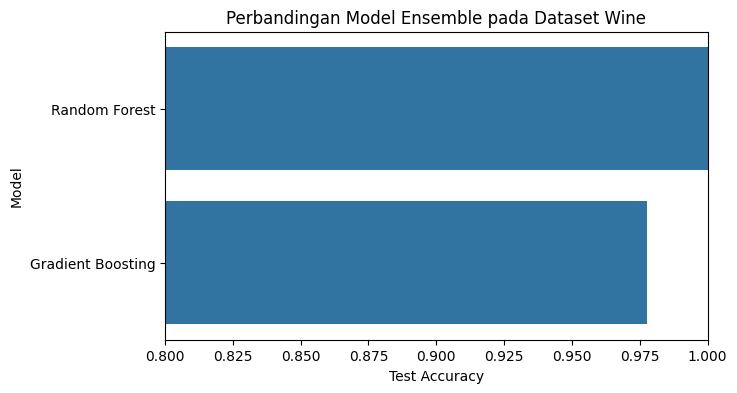

In [31]:
# Visualisasi hasil exercise wine
plt.figure(figsize=(7, 4))
sns.barplot(data=comparison_wine, x="Test Accuracy", y="Model")
plt.title("Perbandingan Model Ensemble pada Dataset Wine")
plt.xlim(0.8, 1.0)
plt.show()

## Kesimpulan Chapter 8

Pada chapter ini dipelajari beberapa algoritma tree-based dan ensemble methods yang sangat penting dalam machine learning.

### Hal-hal utama yang dipelajari:
1. **Decision Tree**
   - mudah dipahami dan divisualisasikan,
   - cocok untuk klasifikasi dan regresi,
   - rawan overfitting jika tidak dibatasi.

2. **Random Forest**
   - menggabungkan banyak decision tree,
   - lebih stabil dan lebih kuat dibanding satu pohon tunggal,
   - mampu memberikan feature importance.

3. **Bagging**
   - membangun banyak model dari bootstrap sample,
   - membantu mengurangi varians model.

4. **Gradient Boosting**
   - membangun model secara bertahap untuk memperbaiki kesalahan sebelumnya,
   - sering memberikan performa tinggi,
   - perlu tuning parameter yang baik.

5. **Hyperparameter Tuning**
   - parameter seperti `max_depth`, `n_estimators`, dan `min_samples_split` sangat memengaruhi performa model,
   - `GridSearchCV` membantu mencari kombinasi parameter terbaik.

6. **Model Comparison**
   - ensemble methods umumnya memberikan performa lebih baik daripada satu decision tree,
   - pemilihan model tetap harus mempertimbangkan akurasi, stabilitas, dan interpretasi.

Secara umum, chapter ini menunjukkan bahwa tree-based methods adalah alat yang sangat kuat dalam machine learning, terutama ketika dikombinasikan dengan teknik ensemble.